# Simulation passage au fin : Lubrification non newtonienne (loi puissance) - Résolution numérique thermique

Dans ce notebook, on repart des profils de vitesse obtenus par théorie de la lubrification dans la configuration de passage au fin simplifiée et nous intégrons numériquement l'équation de la température dans le domaine.


## 1. Import des bibliothèques

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

## 2. Paramètres physiques et domaine de calcul

In [54]:
h = 1.0
K = 150000.0
n = 0.2
Ny = 500
y = np.linspace(0, h, Ny)

# ============================================================
# PARAMÈTRES THERMIQUES
# ============================================================

rho = 1000.0      # masse volumique
cp  = 2000.0      # capacité calorifique
kth = 0.2         # conductivité thermique

T0 = 370.0        # température d'entrée
Tw = 370.0        # température des cylindres (isothermes)

## 3. Cas 4 (rappel) : passage au fin avec débit imposé

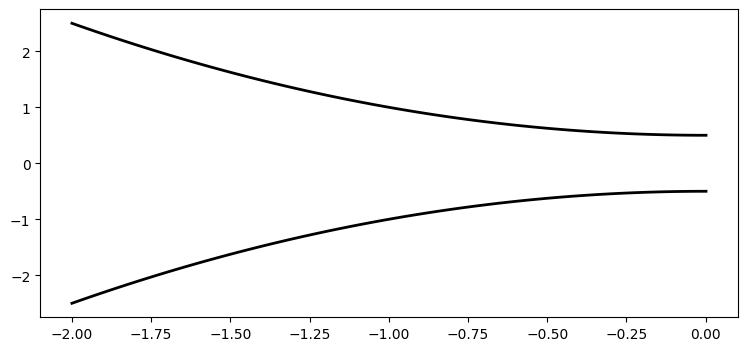

In [55]:

# ============================================================
# PARAMÈTRES PHYSIQUES ET GEOMETRIQUES
# ============================================================

friction=1.1
U_lower = 0.5
U_upper = U_lower*friction

# Débit imposé (différent du Couette pur)
Q_couette_0 = 0.5 * (U_lower + U_upper) * h
Q_cyl = 1.2 * Q_couette_0

p = (n + 1) / n

# Géométrie cylindres (approchée parabolique)
R1 = 1.0
R2 = 1.0
h0 = 1.0

L = 2.0
Nx = 80
x_cyl = np.linspace(-L, 0.001, Nx)

h_cyl = h0 + 0.5 * x_cyl**2 * (1/R1 + 1/R2)

plt.figure(figsize=(9, 4))
plt.plot(x_cyl, -h_cyl/2, 'k', lw=2)
plt.plot(x_cyl,  h_cyl/2, 'k', lw=2)


In [56]:
# ============================================================
# RÉSOLUTION DE C POUR UN S DONNÉ (PROBLÈME COUETTE)
# ============================================================

def solve_C_for_S(S, h, U0, Uh):
    def F(C):
        return S * (abs(h + C)**p - abs(C)**p) - (Uh - U0)
    return brentq(F, -10*h, 10*h)

# ============================================================
# CALCUL DU DÉBIT POUR UN S DONNÉ
# ============================================================

def compute_Q_for_S(S, h, U0, Uh):
    C = solve_C_for_S(S, h, U0, Uh)
    C2 = U0 - S * abs(C)**p
    y = np.linspace(0, h, Ny)
    u = S * abs(y + C)**p + C2
    return np.trapz(u, y)

# ============================================================
# MÉTHODE DE TIR SUR S (PAR BRENT)
# ============================================================

def find_S_for_Q(h, U0, Uh, Q_target):
    Q_couette = 0.5 * (U0 + Uh) * h
    if abs(Q_target - Q_couette) < 1e-10:
        return 0.0

    Smin, Smax = -1.0, 1.0
    while (compute_Q_for_S(Smin, h, U0, Uh) - Q_target) * \
          (compute_Q_for_S(Smax, h, U0, Uh) - Q_target) > 0:
        Smin *= 2
        Smax *= 2

    return brentq(lambda S: compute_Q_for_S(S, h, U0, Uh) - Q_target,
                  Smin, Smax)


def cyl_velocity_profile(y, h, C, S, n, U_lower, U_upper):
    """
    Profil de vitesse Couette–Poiseuille (loi puissance)
    en repère physique y ∈ [0, h].

    Paramètres
    ----------
    y : array
        Coordonnée verticale dans [0, h]
    h : float
        Épaisseur du film
    C, S : floats
        Paramètres issus de la méthode de tir
    n : float
        Indice loi puissance
    U_lower, U_upper : floats
        Vitesses imposées aux parois y=0 et y=h

    Retour
    ------
    u : array
        Profil de vitesse u(y)
    """
    p = (n + 1) / n
    C2 = U_lower - S * abs(C)**p
    return S * abs(y + C)**p + C2

In [57]:
# ============================================================
# RÉSOLUTION MECA LOCALE À CHAQUE x
# ============================================================

C_x = np.zeros(Nx)
S_x = np.zeros(Nx)

for i in range(Nx):
    hi = h_cyl[i]
    S_x[i] = find_S_for_Q(hi, U_lower, U_upper, Q_cyl)
    C_x[i] = solve_C_for_S(S_x[i], hi, U_lower, U_upper)

## 5. Discrétisation par différences finies pour résolution thermique

In [62]:

# Grille thermique
T = np.zeros((Nx, Ny))

# Condition initiale en entrée
T[0, :] = T0

for i in range(Nx-1):

    dx = x_cyl[i+1] - x_cyl[i]
    hi = h_cyl[i]

    # grille locale en y (repère [0,h])
    y = np.linspace(0.0, hi, Ny)
    dy = y[1] - y[0]

    # profil de vitesse
    u = cyl_velocity_profile(
        y, hi,
        C_x[i], S_x[i],
        n, U_lower, U_upper
    )

    # cisaillement du/dy
    dud_y = np.gradient(u, dy)

    # terme de dissipation
    Phi = K * np.abs(dud_y)**(n+1)

    # Matrice diffusion en y
    A = np.zeros((Ny, Ny))
    b = np.zeros(Ny)

    for j in range(1, Ny-1):
        A[j, j-1] =  -kth / dy**2
        A[j, j]   = 2*kth / dy**2 + rho*cp*u[j]/dx
        A[j, j+1] =  -kth / dy**2

        b[j] = rho*cp*u[j]*T[i, j]/dx + Phi[j]

    # Conditions aux parois (Dirichlet)
    A[0, 0] = 1.0
    b[0]    = Tw

    A[-1, -1] = 1.0
    b[-1]     = Tw

    # Résolution
    T[i+1, :] = np.linalg.solve(A, b)

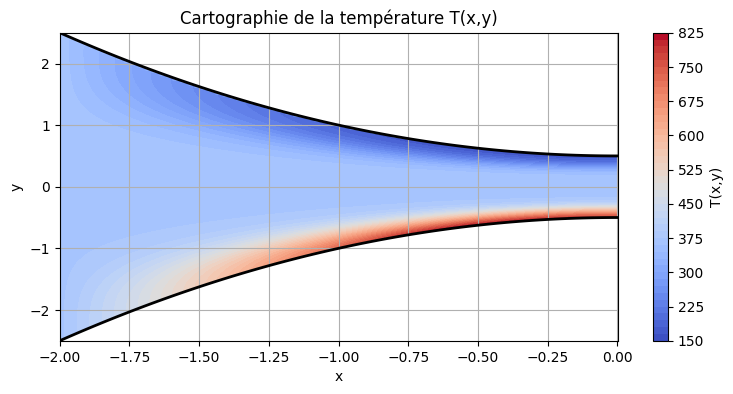

In [61]:
# ============================================================
# VISUALISATION T(x,y)
# ============================================================
from matplotlib.tri import Triangulation

X_pts = []
Y_pts = []
T_pts = []

Ny_loc = Ny

for i in range(len(x_cyl)):
    xi = x_cyl[i]
    hi = h_cyl[i]

    # -----------------------------
    # REPÈRE PHYSIQUE [0,h]
    # -----------------------------
    y_phys = np.linspace(0.0, hi, Ny_loc)

    # -----------------------------
    # REPÈRE DE VISUALISATION CENTRÉ
    # -----------------------------
    y_plot = y_phys - hi/2

    X_pts.extend(xi * np.ones_like(y_plot))
    Y_pts.extend(y_plot)
    T_pts.extend(T[i,:])

X_pts = np.array(X_pts)
Y_pts = np.array(Y_pts)
T_pts = np.array(T_pts)


# ------------------------------------------------------------
# Triangulation
# ------------------------------------------------------------
tri = Triangulation(X_pts, Y_pts)

# ------------------------------------------------------------
# Masque géométrique basé sur l'entrefer local
# ------------------------------------------------------------
mask = np.zeros(len(tri.triangles), dtype=bool)

for k, tri_idx in enumerate(tri.triangles):
    xs = X_pts[tri_idx]
    ys = Y_pts[tri_idx]

    x_c = xs.mean()
    y_c = ys.mean()

    h_loc = np.interp(x_c, x_cyl, h_cyl)

    if not (-h_loc/2 <= y_c <= h_loc/2):
        mask[k] = True

tri.set_mask(mask)

# ------------------------------------------------------------
# Visualisation
# ------------------------------------------------------------
plt.figure(figsize=(9, 4))

plt.plot(x_cyl, -h_cyl/2, 'k', lw=2)
plt.plot(x_cyl,  h_cyl/2, 'k', lw=2)

cont = plt.tricontourf(
    tri, T_pts,
    levels=50,
    cmap="coolwarm")

plt.colorbar(cont, label="T(x,y)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Cartographie de la température T(x,y)")
plt.grid()
plt.show()